In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
f_sig = "../coffea/AllInOne_2022/Resolution_new_lxy.coffea"

sig_histo = util.load(f_sig) [0]


                                      mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  10.5    1.0  10.0  10.0  11.0    0.1   

                                                                      name  
sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  sig_2022_Mchi-10p5_dMchi-1p0_ctau-10  
                                     mchi  dmchi  ctau    m1    m2  delta  \
sig_2022_Mchi-11p0_dMchi-2p0_ctau-1  11.0    2.0   1.0  10.0  12.0    0.2   

                                                                    name  
sig_2022_Mchi-11p0_dMchi-2p0_ctau-1  sig_2022_Mchi-11p0_dMchi-2p0_ctau-1  
                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  11.0    2.0  100.0  10.0  12.0    0.2   

                                                                        name  
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  
                                     mchi  dmchi  ctau    m1    m

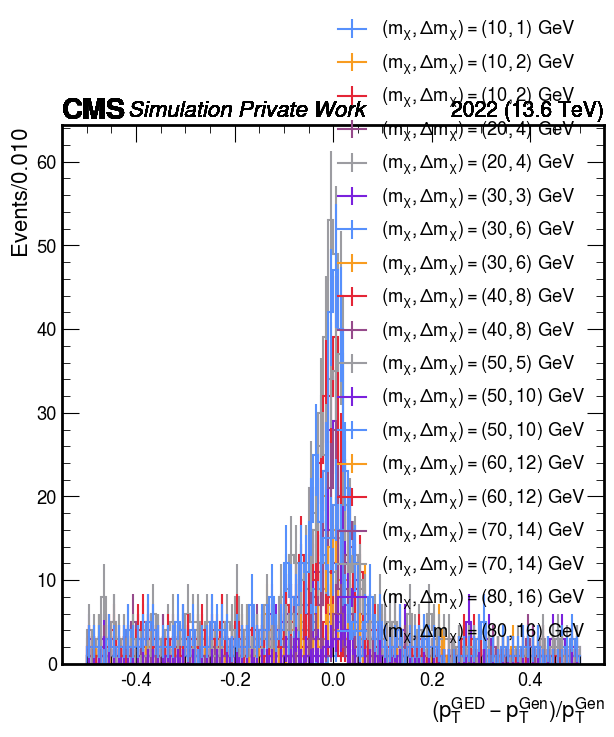

In [3]:
fig, ax = plt.subplots(figsize=(7,7))

# Plot settings
plot_dict = {
    'variable':'res_GED_gen',
    'cut': 'cut1',
    'year': 2022
}
style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points
samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
         0.2: [1,100],
    }
 
}

h_list_lpt=[]
h_sum_lpt = 0

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_1D_return_histo(sig_histo, m1, delta, ctau, plot_dict, style_dict)
            h_list_lpt.append(h_lpt)
            h_sum_lpt=h_sum_lpt+h_lpt

counts_lpt = h_sum_lpt.values()
edges_lpt = h_sum_lpt.axes[0].edges

bin_x_lpt = (edges_lpt[1:]+edges_lpt[:-1])/2



variances_lpt = h_sum_lpt.variances()
yerr_lpt = np.sqrt(variances_lpt)

print (yerr_lpt)


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


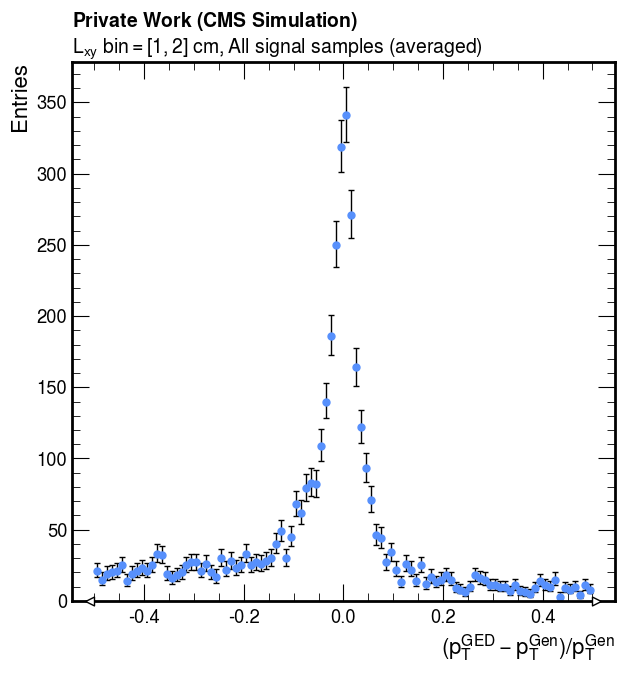

In [4]:
fig, ax = plt.subplots(figsize=(7,7))

mplhep.histplot(h_sum_lpt, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black')

plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{L_{xy}\ bin = [1,2]\ cm, All\ signal\ samples\ (averaged) }$",
    fontsize=14,
    loc="left",
)

plt.show()

In [5]:
#1. Define your model

def double_cb(x,u,sig, nl, a_l, nr, a_r,N):
    t=(x-u)/(sig)
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t>-al) & (t<ar)
    right_tail = t > ar

    y=np.empty_like(t)

    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl / al)**nl * np.exp(-0.5 * al**2)
    B_L = (nl / al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
    B_R = (nr / ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y


In [6]:
#2. Put your data

counts_lpt = h_sum_lpt.values()
edges_lpt = h_sum_lpt.axes[0].edges

bin_x_lpt = (edges_lpt[1:]+edges_lpt[:-1])/2

variances_lpt = h_sum_lpt.variances()
yerr_lpt = np.sqrt(variances_lpt)


xdata = bin_x_lpt
ydata = counts_lpt


mask = ydata >0
ydata_new =ydata[mask]


xdata_new = xdata[mask]

yerr_new_lpt = yerr_lpt[mask]

# print (xdata_new)
print (ydata_new)
print (yerr_new_lpt)


[ 21.  15.  19.  20.  21.  25.  14.  19.  21.  23.  21.  25.  33.  32.
  19.  16.  18.  20.  25.  27.  27.  21.  26.  20.  17.  30.  22.  28.
  23.  25.  33.  25.  27.  26.  28.  30.  40.  49.  30.  45.  68.  62.
  79.  83.  82. 109. 140. 186. 250. 319. 341. 271. 164. 122.  93.  71.
  46.  44.  27.  34.  22.  13.  26.  22.  14.  25.  12.  17.  13.  15.
  18.  15.   9.   8.   6.  10.  18.  16.  15.  11.  11.  10.  10.   7.
  11.   7.   6.   5.   9.  14.  11.  10.  15.   3.   9.   8.  10.   4.
  11.   8.]
[ 4.58257569  3.87298335  4.35889894  4.47213595  4.58257569  5.
  3.74165739  4.35889894  4.58257569  4.79583152  4.58257569  5.
  5.74456265  5.65685425  4.35889894  4.          4.24264069  4.47213595
  5.          5.19615242  5.19615242  4.58257569  5.09901951  4.47213595
  4.12310563  5.47722558  4.69041576  5.29150262  4.79583152  5.
  5.74456265  5.          5.19615242  5.09901951  5.29150262  5.47722558
  6.32455532  7.          5.47722558  6.70820393  8.24621125  7.87400787
  8.

[mean, sigma, nl, al, nr, ar, N]= [6.23805986e-04 3.91239424e-03 9.13136899e-01 3.41336181e-01
 1.39182056e+00 3.22022732e-01 4.98801433e+02]
chi2ndof= 2.1730810563714007
mean  = 0.00062 ± 87.27386
sigma = 0.00391 ± 4518.84895
nl    = 0.91314 ± 0.04867
al    = 0.34134 ± 307548.04673
nr    = 1.39182 ± 0.08462
ar    = 0.32202 ± 318812.06572
N     = 498.80143 ± 63325963.54968


/tmp/ipykernel_2593521/3392158735.py:16: RuntimeWarning: invalid value encountered in scalar power
  A_L = (nl / al)**nl * np.exp(-0.5 * al**2)
/tmp/ipykernel_2593521/3392158735.py:20: RuntimeWarning: invalid value encountered in scalar power
  A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
/tmp/ipykernel_2593521/3392158735.py:18: RuntimeWarning: invalid value encountered in power
  y[left_tail] = A_L / (B_L - t[left_tail])**nl
/tmp/ipykernel_2593521/3392158735.py:22: RuntimeWarning: invalid value encountered in power
  y[right_tail] = A_R / (B_R + t[right_tail])**nr
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


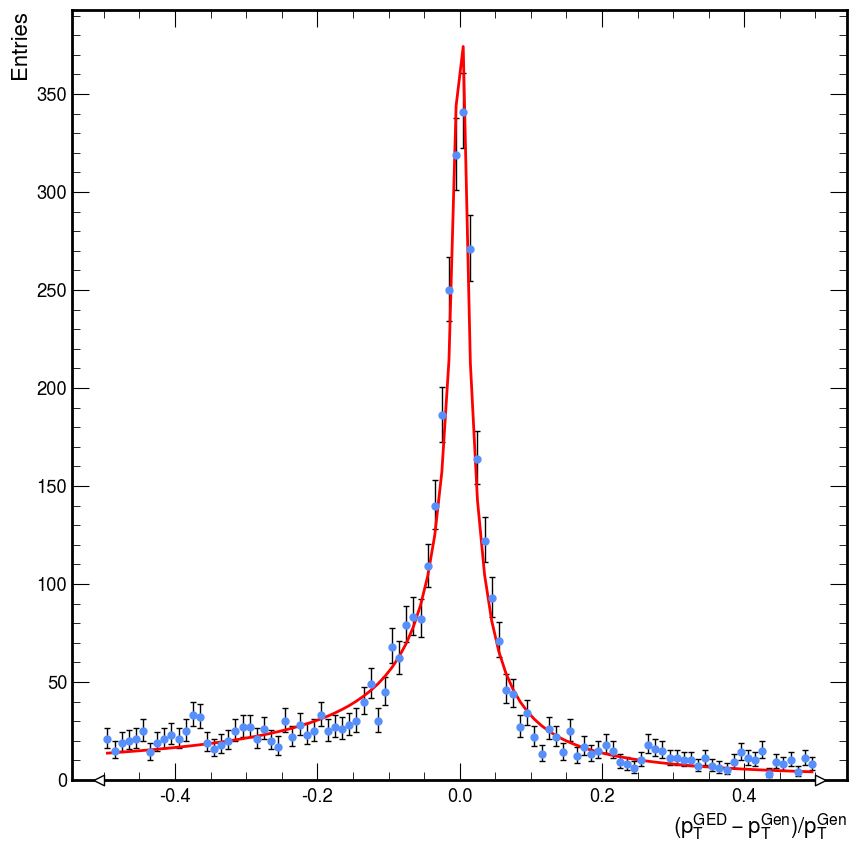

In [7]:
#3. Curve fit 
from scipy.optimize import curve_fit

initial_guess = [0.000672, 0.02265, 30, 0.2, 10, 0.2,ydata_new.max()] #[mean, sigma, nl, al, nr, ar, N]

popt, pcov = curve_fit(double_cb, xdata_new, ydata_new, p0=initial_guess, sigma=yerr_new_lpt, absolute_sigma=True)

mplhep.histplot(h_sum_lpt, histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black', label='Histogram')

plt.plot(xdata_new, double_cb(xdata_new, *popt), label='Double Crystal Ball Fit', color='red', linewidth=2)


plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

print ("[mean, sigma, nl, al, nr, ar, N]=", popt)

yp = double_cb(xdata_new, *popt)

eq = (ydata_new-yp)/(yerr_new_lpt)
chi2 = np.sum(eq**2)

ndof = len(ydata_new) - len(popt)

chi2ndof = chi2/ndof
print ("chi2ndof=", chi2ndof)

perr = np.sqrt(np.diag(pcov))
names = ["mean", "sigma", "nl", "al", "nr", "ar", "N"]

for name, value, error in zip(names, popt, perr):
    print(f"{name:5s} = {value:.5f} ± {error:.5f}")



In [8]:
perr = np.sqrt(np.diag(pcov))
names = ["mean", "sigma", "nl", "al", "nr", "ar", "N"]

for name, value, error in zip(names, popt, perr):
    print(f"{name:5s} = {value:.5f} ± {error:.5f}")

mean  = 0.00062 ± 87.27386
sigma = 0.00391 ± 4518.84895
nl    = 0.91314 ± 0.04867
al    = 0.34134 ± 307548.04673
nr    = 1.39182 ± 0.08462
ar    = 0.32202 ± 318812.06572
N     = 498.80143 ± 63325963.54968
